Idea is not to get state of the art sentiment analyser but to train a custom llm from scratch

In [1]:
#%pip install pytorch-nlp

In [109]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [110]:
from torchnlp.datasets import imdb_dataset
imdb_dataset()

()

In [111]:
import random
import numpy as np

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()

In [112]:
from pathlib import Path
import textwrap

text = Path("./data/aclImdb/train/pos/0_9.txt").read_text(encoding="utf-8")
print(textwrap.fill(text, width=80))

Bromwell High is a cartoon comedy. It ran at the same time as some other
programs about school life, such as "Teachers". My 35 years in the teaching
profession lead me to believe that Bromwell High's satire is much closer to
reality than is "Teachers". The scramble to survive financially, the insightful
students who can see right through their pathetic teachers' pomp, the pettiness
of the whole situation, all remind me of the schools I knew and their students.
When I saw the episode in which a student repeatedly tried to burn down the
school, I immediately recalled ......... at .......... High. A classic line:
INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell
High. I expect that many adults of my age think that Bromwell High is far
fetched. What a pity that it isn't!


In [113]:
train_pos_path = './data/aclImdb/train/pos/'
train_neg_path = './data/aclImdb/train/neg/'
test_pos_path =  './data/aclImdb/test/pos/' 
test_neg_path =  './data/aclImdb/test/neg/' 

In [114]:
import os
def load_dataset(folder):
    reviews = []
    for filename in os.listdir(folder):
        if filename.endswith(".txt"):
            file_path = os.path.join(folder, filename)
            with open(file_path, "r", encoding="utf-8") as f:
                reviews.append(f.read())
    return reviews

In [115]:
train_pos = load_dataset(train_pos_path)
train_neg = load_dataset(train_neg_path)

In [116]:
test_pos = load_dataset(test_pos_path)
test_neg = load_dataset(test_neg_path)

In [117]:
len(train_pos),len(train_neg),len(test_pos),len(test_neg)

(12500, 12500, 12500, 12500)

In [118]:
import numpy as np
import pandas as pd

train_df = pd.DataFrame({
    'review': train_pos + train_neg,
    'label': [1] * len(train_pos) + [0] * len(train_neg)
})

test_df = pd.DataFrame({
    'review': test_pos + test_neg,
    'label': [1] * len(test_pos) + [0] * len(test_neg)
})

print(train_df.head())

                                              review  label
0  Bromwell High is a cartoon comedy. It ran at t...      1
1  Homelessness (or Houselessness as George Carli...      1
2  Brilliant over-acting by Lesley Ann Warren. Be...      1
3  This is easily the most underrated film inn th...      1
4  This is not the typical Mel Brooks film. It wa...      1


### 2. Explore the Dataset

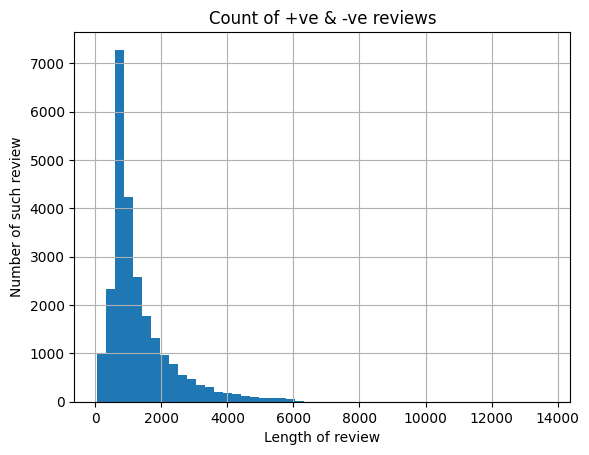

In [119]:
import matplotlib.pyplot as plt 
train_df["length"] = train_df["review"].apply(lambda x: len(x))
train_df["length"].hist(bins=50)
plt.xlabel("Length of review")
plt.ylabel("Number of such review")
plt.title("Count of +ve & -ve reviews")
plt.show()

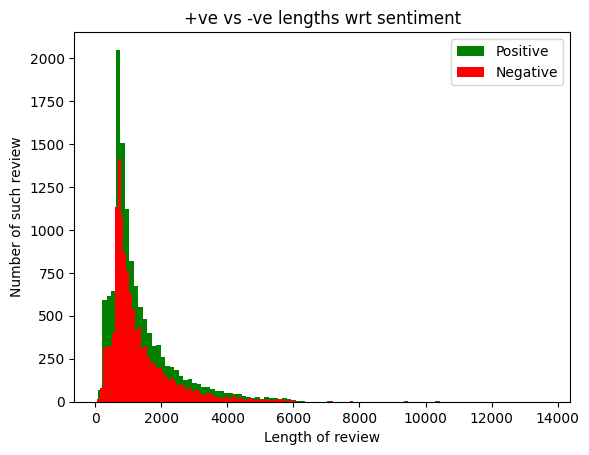

In [120]:
train_df[train_df["label"]==1]["length"].plot(kind="hist", bins=100, color="g", label="Positive")
train_df[train_df["label"]==0]["length"].plot(kind="hist", bins=100, color="r", label="Negative")
plt.xlabel("Length of review")
plt.ylabel("Number of such review")
plt.title("+ve vs -ve lengths wrt sentiment")
plt.legend()
plt.show()

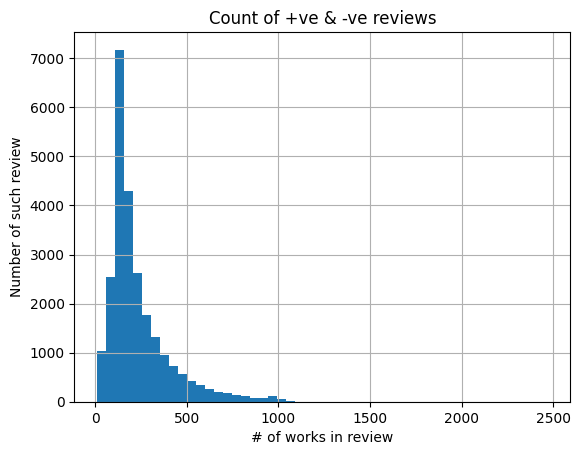

In [121]:
import matplotlib.pyplot as plt 
train_df["words"] = train_df["review"].apply(lambda x: len(x.split(' ')))
train_df["words"].hist(bins=50)
plt.xlabel("# of works in review")
plt.ylabel("Number of such review")
plt.title("Count of +ve & -ve reviews")
plt.show()

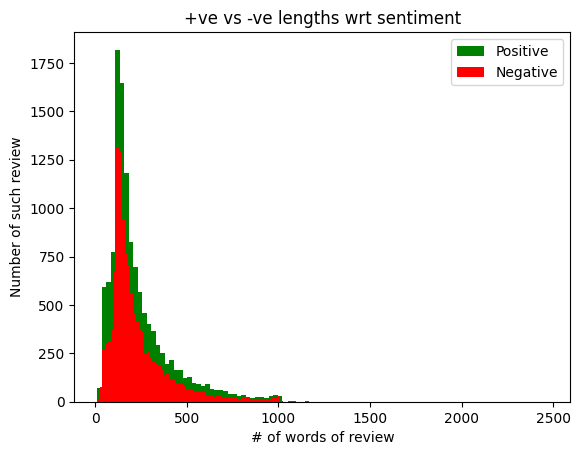

In [122]:
train_df[train_df["label"]==1]["words"].plot(kind="hist", bins=100, color="g", label="Positive")
train_df[train_df["label"]==0]["words"].plot(kind="hist", bins=100, color="r", label="Negative")
plt.xlabel("# of words of review")
plt.ylabel("Number of such review")
plt.title("+ve vs -ve lengths wrt sentiment")
plt.legend()
plt.show()

# Observations :
1. okay so both +Ve & -ve are tailed distribution
2. Looks like it goes up & then starts falling around 1k characters
3. suprising part is that people are writing more than 4k characters as review in both +ve & -ve reviews

Let me zoom into the 1k range & see the distribution again , also i think i want to see the longer reviews

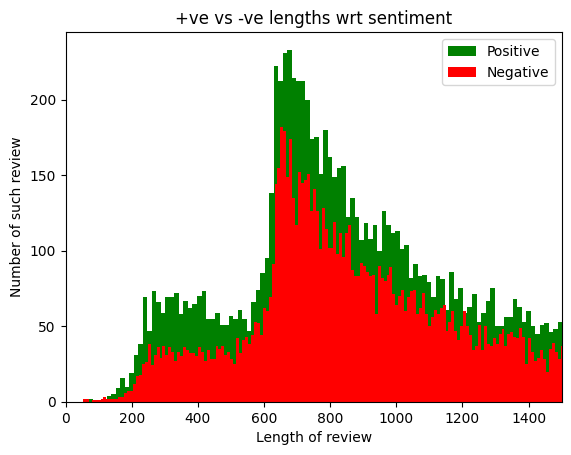

In [123]:
train_df[train_df["label"]==1]["length"].plot(kind="hist", bins=1000, color="g", label="Positive")
train_df[train_df["label"]==0]["length"].plot(kind="hist", bins=1000, color="r", label="Negative")
plt.xlabel("Length of review")
plt.ylabel("Number of such review")
plt.title("+ve vs -ve lengths wrt sentiment")
plt.xlim(0, 1500)
plt.legend()
plt.show()

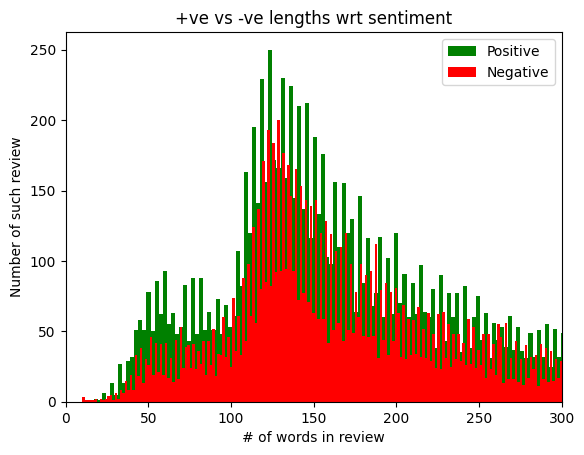

In [124]:
train_df[train_df["label"]==1]["words"].plot(kind="hist", bins=1000, color="g", label="Positive")
train_df[train_df["label"]==0]["words"].plot(kind="hist", bins=1000, color="r", label="Negative")
plt.xlabel("# of words in review")
plt.ylabel("Number of such review")
plt.title("+ve vs -ve lengths wrt sentiment")
plt.xlim(0, 300)
plt.legend()
plt.show()

# Observations :

1. length 0f chars & # of words increases & drops . 
2. Peaks around 600-650 chaharacters  & ~120 words before dropping off.
3. We can try ~120 words worth of tokens for max_length 

Lets looks at some exmaples & then box plot as wel

In [125]:
neg = train_df[train_df['label']==0]
small  = neg[neg['length']<100].iloc[-1]['review']
print(small,end='\n\n')
large = neg[neg['length']>2000].iloc[-1]['review']
print(large[:100])

Long, boring, blasphemous. Never have I been so glad to see ending credits roll.

Hmmm, a sports team is in a plane crash, gets stranded on a snowy mountain, and is faced with the di


<Figure size 800x500 with 0 Axes>

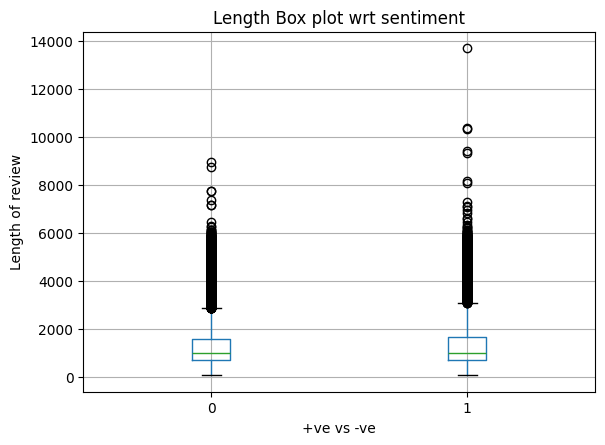

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
train_df.boxplot(column="length", by="label", grid=True)

plt.xlabel("+ve vs -ve")
plt.ylabel("Length of review")
plt.title("Length Box plot wrt sentiment")
plt.suptitle("")  # remove automatic subtitle
plt.show()



Observations :
1. So the distribution is very similar wrt length . As expected we cant use length as a major classification criteria

In [127]:
train_df.drop(columns=['length','words'])

,review,label
0,Bromwell High is a cartoon comedy. It ran at t...,1
1,Homelessness (or Houselessness as George Carli...,1
2,Brilliant over-acting by Lesley Ann Warren. Be...,1
3,This is easily the most underrated film inn th...,1
4,This is not the typical Mel Brooks film. It wa...,1
...,...,...
24995,"Towards the end of the movie, I felt it was to...",0
24996,This is the kind of movie that my enemies cont...,0
24997,I saw 'Descent' last night at the Stockholm Fi...,0
24998,Some films that you pick up for a pound turn o...,0


In [128]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df["label"],
    random_state=42
)

In [129]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [130]:
AutoTokenizer?

Init signature: AutoTokenizer()
Docstring:     
This is a generic tokenizer class that will be instantiated as one of the tokenizer classes of the library when
created with the [`AutoTokenizer.from_pretrained`] class method.

This class cannot be instantiated directly using `__init__()` (throws an error).
File:           d:\_self_masters\_udacity_masters\env_python\pytorch_env\lib\site-packages\transformers\models\auto\tokenization_auto.py
Type:           type
Subclasses:     

In [137]:
sample_texts = train_df['review'].sample(2, random_state=42).tolist()
tokenized_samples = tokenizer(sample_texts, truncation=True, padding="max_length", max_length=256, return_tensors="pt")
print(tokenized_samples)

{'input_ids': tensor([[  101,  1999,  6634,  1999,  1996,  4534,  2957, 15536, 22117, 17007,
          3248,  1057,  1012,  1055,  1012,  3212,  3460,  2040,  2038,  2010,
          2733, 12726,  2135,  7153,  2007,  1037, 11547,  2008,  3397, 11629,
          1012,  2004,  8872,  2703,  5203,  7919,  2685,  2041,  1996,  3124,
          2351,  2013,  2048, 10432,  1999,  1996,  3108,  1012,  2008,  1005,
          1055,  2025,  1996,  3277,  2182,  1010,  1996,  2048,  1997,  2068,
          2468, 15175,  5826,  1999,  2019,  3947,  2000,  2424,  1996, 15978,
          1998,  3087,  2842,  6086,  2000,  1996,  4295,  1012,  1026,  7987,
          1013,  1028,  1026,  7987,  1013,  1028,  2004,  2001,  4197,  2041,
          2011,  2151,  2193,  1997,  2111,  1010,  2005,  2070,  3114,  2472,
         12005,  2050, 22001,  2106,  2025,  8572,  2000,  3459,  1996,  2235,
          3033,  2007,  3087,  2008,  4165,  2066,  2027,  1005,  2128,  2013,
          5773,  1012,  2383,  2042,  

In [138]:
type(tokenized_samples)

transformers.tokenization_utils_base.BatchEncoding

In [139]:
lengths = [
    len(tokenizer.encode(text))
    for text in train_data['review'].sample(1000)
]
print("mean:", np.mean(lengths))
print("95th percentile:", np.percentile(lengths, 95))
print("max:", max(lengths))

mean: 317.111
95th percentile: 768.3499999999997
max: 1959


In [140]:
# lets see how 128 tokens will do ; small gpu will have memory constaints

In [141]:
MAX_LENGTH = 256

In [142]:
class IMDBDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=MAX_LENGTH):
        self.max_length = max_length
        encoded = tokenizer(
            data['review'].tolist(),
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt"
        )

        self.input_ids = encoded['input_ids']
        self.attention_mask = encoded['attention_mask']
        self.labels = torch.tensor(data['label'].values)
        
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.input_ids[idx],
            self.attention_mask[idx],
            self.labels[idx]
        )

In [143]:
#val_dataset = IMDBDataset(val_data, tokenizer)
#val_dataset[0]
train_dataset = IMDBDataset(train_data, tokenizer)
val_dataset = IMDBDataset(val_data, tokenizer)
test_dataset = IMDBDataset(test_df, tokenizer)

In [144]:
len(train_dataset),len(val_dataset)

(22500, 2500)

In [145]:
tokens = tokenizer.convert_ids_to_tokens(tokenized_samples['input_ids'][0])
print(tokens[:5])

['[CLS]', 'in', 'panic', 'in', 'the']


In [146]:
#train_dataset[0]

In [147]:
from torch.utils.data import DataLoader

# Define batch size
BATCH_SIZE = 32

# Create DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [148]:
input_ids, attention_mask,label = train_dataset[0]
assert isinstance(input_ids, torch.Tensor)
assert input_ids.shape[0] == train_dataset.max_length

print(type(attention_mask),type(label))

<class 'torch.Tensor'> <class 'torch.Tensor'>


In [149]:
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 128,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 4,
    "head_size": 32,  # 4 heads * 32 = 128 -> matches d_embed
    "dropout_rate": 0.2,
    "use_bias": True
}

In [150]:
import torch.nn as nn
import math

class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.Q_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.K_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.V_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.dropout = nn.Dropout(config["dropout_rate"])


    def forward(self, input,attention_mask):
        batch_size, tokens_num, d_embed = input.shape
        Q = self.Q_weights(input)  # (B, T, head_size)
        K = self.K_weights(input)  # (B, T, head_size)
        V = self.V_weights(input)  # (B, T, head_size)

        # Q @ K^T => (B, T, T)
        attention_scores = Q @ K.transpose(1, 2)

        mask = attention_mask.unsqueeze(1).expand(-1, tokens_num, -1)
        attention_scores = attention_scores.masked_fill(mask == 0, float('-inf'))
    
        attention_scores = attention_scores / math.sqrt(K.shape[-1])
        attention_scores = torch.softmax(attention_scores, dim=-1)
        attention_scores = self.dropout(attention_scores)

        return attention_scores @ V

In [151]:
attention_head = AttentionHead(config).to(device)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)
dummy_attention = torch.ones(BATCH_SIZE,config["context_size"]).to(device)
attention_output = attention_head(dummy_input,dummy_attention)
print("AttentionHead output shape:", attention_output.shape)

AttentionHead output shape: torch.Size([32, 256, 32])


In [152]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        heads_list = [AttentionHead(config) for _ in range(config["heads_num"])]
        self.heads = nn.ModuleList(heads_list)

        self.linear = nn.Linear(config["heads_num"] * config["head_size"], config["d_embed"])
        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input,mask):
        heads_outputs = [head(input,mask) for head in self.heads]
        x = torch.cat(heads_outputs, dim=-1)  # (B, T, heads_num * head_size)
        x = self.linear(x)                   # (B, T, d_embed)
        x = self.dropout(x)
        return x

In [153]:
multi_head_attention = MultiHeadAttention(config).to(device)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)
dummy_attention = torch.ones(BATCH_SIZE,config["context_size"]).to(device)
mha_output = multi_head_attention(dummy_input,dummy_attention)
print("MultiHeadAttention output shape:", mha_output.shape)

MultiHeadAttention output shape: torch.Size([32, 256, 128])


In [154]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.linear_layers = nn.Sequential(
            nn.Linear(config["d_embed"], 4 * config["d_embed"]),
            nn.GELU(),
            nn.Linear(4 * config["d_embed"], config["d_embed"]),
            nn.Dropout(config["dropout_rate"])
        )

    def forward(self, input):
        return self.linear_layers(input)

In [155]:
feed_forward = FeedForward(config).to(device)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)
ff_output = feed_forward(dummy_input)
print("FeedForward output shape:", ff_output.shape)

FeedForward output shape: torch.Size([32, 256, 128])


In [156]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.multi_head = MultiHeadAttention(config)
        self.layer_norm_1 = nn.LayerNorm(config["d_embed"])

        self.feed_forward = FeedForward(config)
        self.layer_norm_2 = nn.LayerNorm(config["d_embed"])

    def forward(self, input,mask):
        x = input
        x = x + self.multi_head(self.layer_norm_1(x),mask)
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

In [157]:
block = Block(config).to(device)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)
dummy_attention = torch.ones(BATCH_SIZE,config["context_size"]).to(device)
block_output = block(dummy_input,dummy_attention)
print("Block output shape:", block_output.shape)

Block output shape: torch.Size([32, 256, 128])


In [158]:
class SentimentLLM(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_embedding_layer = nn.Embedding(config["vocabulary_size"], config["d_embed"])
        self.positional_embedding_layer = nn.Embedding(config["context_size"], config["d_embed"])
        self.layers = nn.ModuleList([Block(config) for _ in range(config["layers_num"])])
        self.layer_norm = nn.LayerNorm(config["d_embed"])
        self.out_proj = nn.Linear(config["d_embed"],config['num_classes'],bias=False)
        
    def forward(self, token_ids,mask):
        batch_size, tokens_num = token_ids.shape

        x = self.token_embedding_layer(token_ids)  #(B, T, d_embed)
        positions = torch.arange(tokens_num, device=token_ids.device)#(T,)
        pos_embed = self.positional_embedding_layer(positions)  # (T, d_embed)
        x = x + pos_embed.unsqueeze(0)  
        
        for block in self.layers:
            x = block(x, mask)  # (B, T, d_embed)
        
        x = self.layer_norm(x)
        #x = x.mean(dim=1)
        x = x[:, 0, :] #CLS Token
        logits = self.out_proj(x)
        return logits

In [159]:
model = SentimentLLM(config).to(device)

dummy_token_ids = torch.randint(
    0, config["vocabulary_size"], 
    (BATCH_SIZE, config["context_size"])
).to(device)
dummy_attention = torch.ones(BATCH_SIZE,config["context_size"]).to(device)

logits = model(dummy_token_ids,dummy_attention)

print("SentimentLLM output shape:", logits.shape)
print("Logits sample:\n", logits[:2])

SentimentLLM output shape: torch.Size([32, 2])
Logits sample:
 tensor([[ 0.2233, -0.1822],
        [-0.1495, -0.4060]], device='cuda:0', grad_fn=<SliceBackward0>)


In [160]:
assert logits.size(1) == config["num_classes"], (
    f"Expected number of classes {config['num_classes']}, "
    f"but got {logits.size(1)}"
)

assert logits.size(0) == BATCH_SIZE, (
    f"Expected batch size {BATCH_SIZE}, "
    f"but got {logits.size(0)}"
)

In [161]:
def calculate_accuracy(model, data_loader, device):
    model.eval()
    total_correct,total_samples=0,0
    with torch.inference_mode():
        for sample in data_loader:
            inp_id,mask,out = sample
            inp_id= inp_id.to(device)
            mask= mask.to(device)
            out = out.to(device)
            logits = model(inp_id,mask)
            preds = torch.argmax(logits, dim=-1)
            total_correct = total_correct+(out==preds).sum().item()
            total_samples+= len(out)
    accuracy = (total_correct / total_samples) * 100
    return accuracy

# current accuracy without any training should be 50%

In [162]:
validation_accuracy = calculate_accuracy(model, val_loader, device)
print(f"Validation Accuracy: {validation_accuracy:.2f}%")

Validation Accuracy: 50.00%


In [103]:
ITER = 0

In [163]:
ITER+=1

In [105]:
'''
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 20
model = SentimentLLM(config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=1, gamma=0.9)
patience = 4
current_iter_without_improvement = 0
prev_error_mean = np.inf
best_acc = 0.0
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for step, (input_ids, masks , labels) in enumerate(train_loader):
        input_ids = input_ids.to(device)
        labels = labels.to(device)
        masks = masks.to(device)
        logits = model(input_ids,masks)
        loss = criterion(logits,labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_raw = loss.item()
        running_loss += loss_raw
        if (step + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Step [{step+1}/{len(train_loader)}], "
                  f"Loss: {running_loss/100:.4f}")
            running_loss = 0.0
    scheduler.step()
    val_accuracy = calculate_accuracy(model, val_loader, device)
    if val_accuracy > best_acc:
        best_acc = val_accuracy
        torch.save(model.state_dict(), f"best_model_{ITER}.pt")
    else:
        current_iter_without_improvement+=1
    if current_iter_without_improvement>=patience:
        break
    
    print(f"Epoch {epoch+1} - Validation Accuracy: {val_accuracy:.2f}%")

'''

'\nimport torch.optim as optim\nfrom torch.optim.lr_scheduler import StepLR\nimport numpy as np\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\nEPOCHS = 20\nmodel = SentimentLLM(config).to(device)\ncriterion = nn.CrossEntropyLoss()\noptimizer = optim.AdamW(model.parameters(), lr=1e-4)\nscheduler = StepLR(optimizer, step_size=1, gamma=0.9)\npatience = 4\ncurrent_iter_without_improvement = 0\nprev_error_mean = np.inf\nbest_acc = 0.0\nfor epoch in range(EPOCHS):\n    model.train()\n    running_loss = 0.0\n    for step, (input_ids, masks , labels) in enumerate(train_loader):\n        input_ids = input_ids.to(device)\n        labels = labels.to(device)\n        masks = masks.to(device)\n        logits = model(input_ids,masks)\n        loss = criterion(logits,labels)\n        optimizer.zero_grad()\n        loss.backward()\n        optimizer.step()\n        loss_raw = loss.item()\n        running_loss += loss_raw\n        if (step + 1) % 100 == 0:\n            print(f"

In [48]:
test_acc = calculate_accuracy(model, test_loader, device)
print(f"test accuracy is {test_acc}")

test accuracy is 76.592


So using 128 max token length along with above configs give 76% test accuracy

Not sure if this can be the issue though. If i have to write a review i think most people wil describe it first & then explain .

Lets integrate  tensorbaord first

In [107]:
ITER+=1

In [164]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import numpy as np

In [167]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter(
    log_dir=f"runs_{ITER}/sentiment_gpt"
)
model = SentimentLLM(config).to(device)
from torch.optim.lr_scheduler import CosineAnnealingLR
criterion = nn.CrossEntropyLoss()

EPOCHS = 20
best_acc = 0.0
global_step = 0
current_iter_without_improvement = 0 
patience = 3
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for step, (input_ids,mask, labels) in enumerate(train_loader):
        input_ids = input_ids.to(device)
        labels = labels.to(device)
        mask = mask.to(device)
        logits = model(input_ids,mask)
        
        loss = criterion(
            logits,
            labels
        )
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_value = loss.item()
        epoch_loss += loss_value

        writer.add_scalar(
            "Batch Loss/train",
            loss_value,
            global_step
        )
        current_lr = optimizer.param_groups[0]['lr']
        writer.add_scalar(
            "Learning Rate",
            current_lr,
            global_step
        )
        global_step += 1

        if (step + 1) % 100 == 0:
            print(
                f"Epoch [{epoch+1}/{EPOCHS}] "
                f"Step [{step+1}/{len(train_loader)}] "
                f"Loss: {loss_value:.4f}"
            )

    avg_epoch_loss = epoch_loss / len(train_loader)
    val_accuracy = calculate_accuracy(model,val_loader,device)
    
    writer.add_scalar(
        "Epoch Loss/train",
        avg_epoch_loss,
        epoch
    )
    writer.add_scalar(
        "Validation Accuracy",
        val_accuracy,
        epoch
    )

    for name, param in model.named_parameters():
        writer.add_histogram(
            name,
            param,
            epoch
        )
        
    print(f"Epoch {epoch+1} | "f"Loss: {avg_epoch_loss:.4f} | "f"Val Acc: {val_accuracy:.2f}%")
    if val_accuracy > best_acc:
        best_acc = val_accuracy
        torch.save(model.state_dict(),f"best_model_{ITER}.pt")
    else:
        current_iter_without_improvement+=1
    if current_iter_without_improvement>=patience:
        break
    scheduler.step()


    
writer.close()

Epoch [1/20] Step [100/704] Loss: 0.7371
Epoch [1/20] Step [200/704] Loss: 0.6628
Epoch [1/20] Step [300/704] Loss: 0.4631
Epoch [1/20] Step [400/704] Loss: 0.4620
Epoch [1/20] Step [500/704] Loss: 0.5190
Epoch [1/20] Step [600/704] Loss: 0.3580
Epoch [1/20] Step [700/704] Loss: 0.4768
Epoch 1 | Loss: 0.5604 | Val Acc: 78.96%
Epoch [2/20] Step [100/704] Loss: 0.6322
Epoch [2/20] Step [200/704] Loss: 0.3266
Epoch [2/20] Step [300/704] Loss: 0.3423
Epoch [2/20] Step [400/704] Loss: 0.2946
Epoch [2/20] Step [500/704] Loss: 0.3938
Epoch [2/20] Step [600/704] Loss: 0.3396
Epoch [2/20] Step [700/704] Loss: 0.3904
Epoch 2 | Loss: 0.4060 | Val Acc: 81.76%
Epoch [3/20] Step [100/704] Loss: 0.2800
Epoch [3/20] Step [200/704] Loss: 0.2724
Epoch [3/20] Step [300/704] Loss: 0.3056
Epoch [3/20] Step [400/704] Loss: 0.2358
Epoch [3/20] Step [500/704] Loss: 0.4064
Epoch [3/20] Step [600/704] Loss: 0.2715
Epoch [3/20] Step [700/704] Loss: 0.2877
Epoch 3 | Loss: 0.3424 | Val Acc: 82.48%
Epoch [4/20] Ste

In [ ]:
model.load_state_dict(torch.load("best_model_2.pt", map_location=device))

<All keys matched successfully>

In [170]:
test_acc = calculate_accuracy(model, test_loader, device)
print(f"test accuracy is {test_acc}")

test accuracy is 82.57600000000001
